In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sqlite3
from scipy.stats import ttest_ind
import scipy.stats as stats

warnings.filterwarnings('ignore')


In [ ]:
import sqlite3
import pandas as pd

# creating database connection (from Google Drive)
conn = sqlite3.connect('/content/drive/MyDrive/inventory.db')

# fetching vendor sales summary data
df = pd.read_sql_query(
    "SELECT * FROM vendor_sales_summary",
    conn
)

df.head()


,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750,145080,3811251.60,142049.0,5.101920e+06,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750,164038,3804041.22,160247.0,4.819073e+06,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750,187407,3418303.68,187140.0,4.538121e+06,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750,201682,3261197.94,200412.0,4.475973e+06,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750,138109,3023206.01,135838.0,4.223108e+06,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897


In [ ]:
#summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,1.065065e+04,18753.519148,2.00,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,10692.0,1.803923e+04,12662.187074,58.00,5793.500000,18761.500000,25514.250000,9.063100e+04
PurchasePrice,10692.0,2.438530e+01,109.269375,0.36,6.840000,10.455000,19.482500,5.681810e+03
ActualPrice,10692.0,3.564367e+01,148.246016,0.49,10.990000,15.990000,28.990000,7.499990e+03
TotalPurchaseQuantity,10692.0,3.140887e+03,11095.086769,1.00,36.000000,262.000000,1975.750000,3.376600e+05
TotalPurchaseDollars,10692.0,3.010669e+04,123067.799627,0.71,453.457500,3655.465000,20738.245000,3.811252e+06
TotalSalesQuantity,10692.0,3.077482e+03,10952.851391,0.00,33.000000,261.000000,1929.250000,3.349390e+05
TotalSalesDollars,10692.0,4.223907e+04,167655.265984,0.00,729.220000,5298.045000,28396.915000,5.101920e+06
TotalSalesPrice,10692.0,1.879378e+04,44952.773386,0.00,289.710000,2857.800000,16059.562500,6.728193e+05
TotalExciseTax,10692.0,1.774226e+03,10975.582240,0.00,4.800000,46.570000,418.650000,3.682428e+05


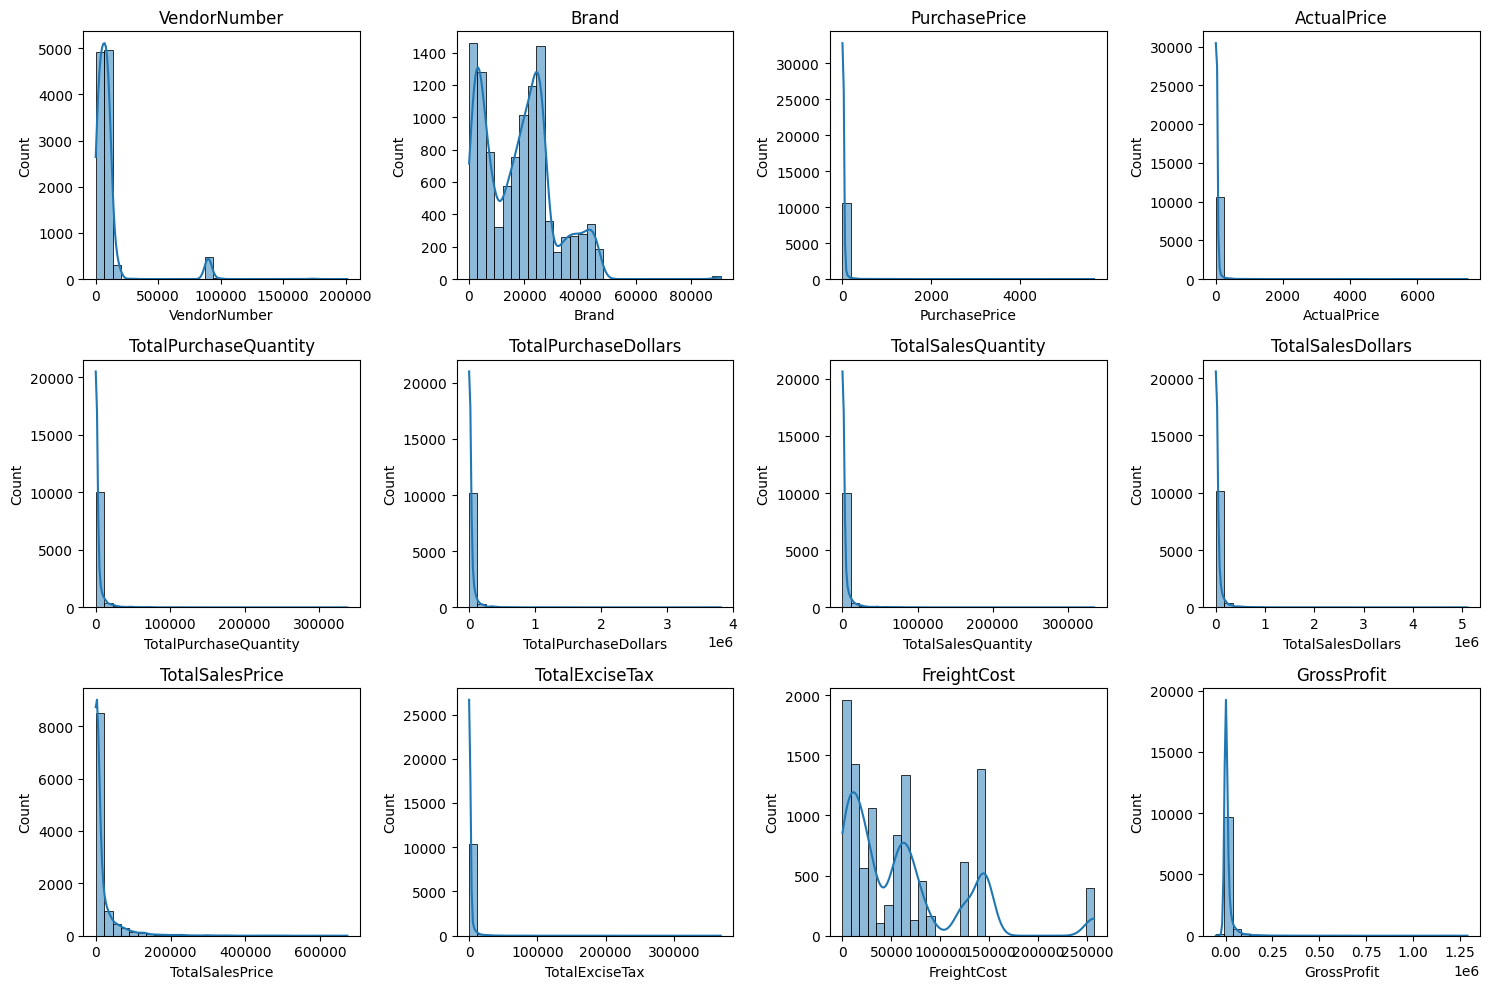

In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns[:12]

plt.figure(figsize=(15, 10))

for i, col in enumerate(numerical_cols):
    plt.subplot(3, 4, i + 1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)

plt.tight_layout()
plt.show()


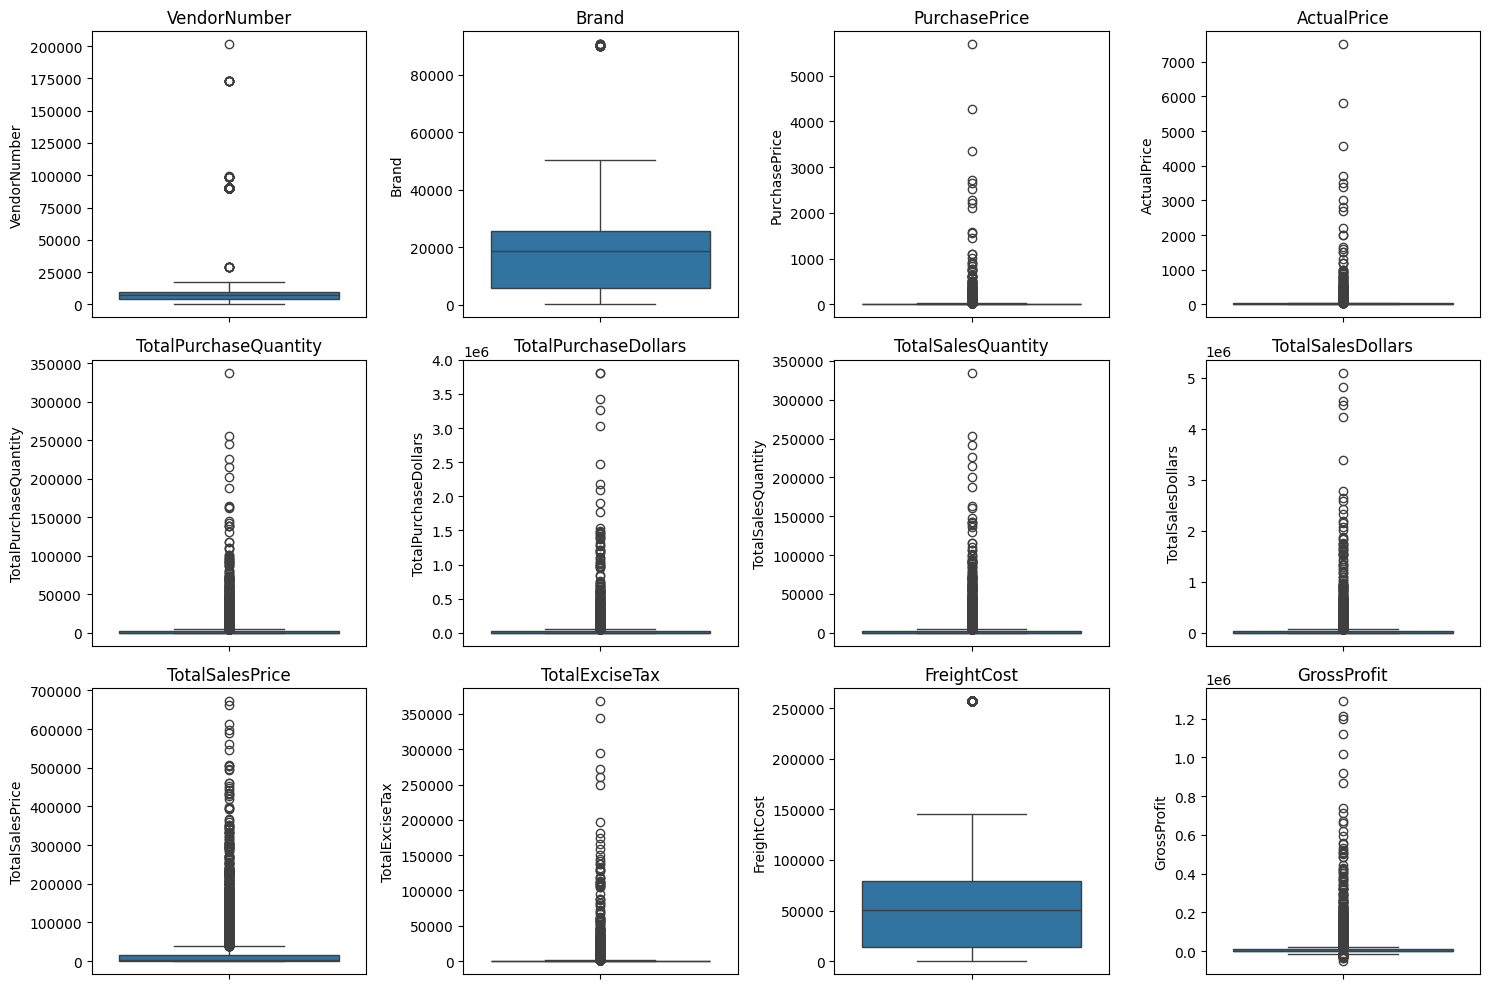

In [ ]:
# Outlier Detection with Boxplots (limited columns)
numerical_cols = df.select_dtypes(include=np.number).columns[:12]

plt.figure(figsize=(15, 10))

for i, col in enumerate(numerical_cols):
    plt.subplot(3, 4, i + 1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()


In [ ]:
# Filter data by removing inconsistencies
df = pd.read_sql_query(
    """
    SELECT *
    FROM vendor_sales_summary
    WHERE GrossProfit > 0
      AND ProfitMargin > 0
      AND TotalSalesQuantity > 0
    """,
    conn
)

df


,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750,145080,3811251.60,142049.0,5.101920e+06,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750,164038,3804041.22,160247.0,4.819073e+06,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750,187407,3418303.68,187140.0,4.538121e+06,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750,201682,3261197.94,200412.0,4.475973e+06,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750,138109,3023206.01,135838.0,4.223108e+06,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8560,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750,2,2.64,5.0,1.595000e+01,10.96,0.55,27100.41,13.31,83.448276,2.500000,6.041667
8561,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,134.0,6.566000e+01,1.47,7.04,50293.62,63.32,96.436186,22.333333,28.059829
8562,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50,2,1.48,2.0,1.980000e+00,0.99,0.10,14069.87,0.50,25.252525,1.000000,1.337838
8563,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,72.0,1.432800e+02,77.61,15.12,257032.07,141.81,98.974037,72.000000,97.469388


In [ ]:
vendor_performance = df.groupby('VendorName').agg({
    'TotalPurchaseDollars': 'sum',
    'GrossProfit': 'sum',
    'TotalSalesDollars': 'sum'
}).reset_index()


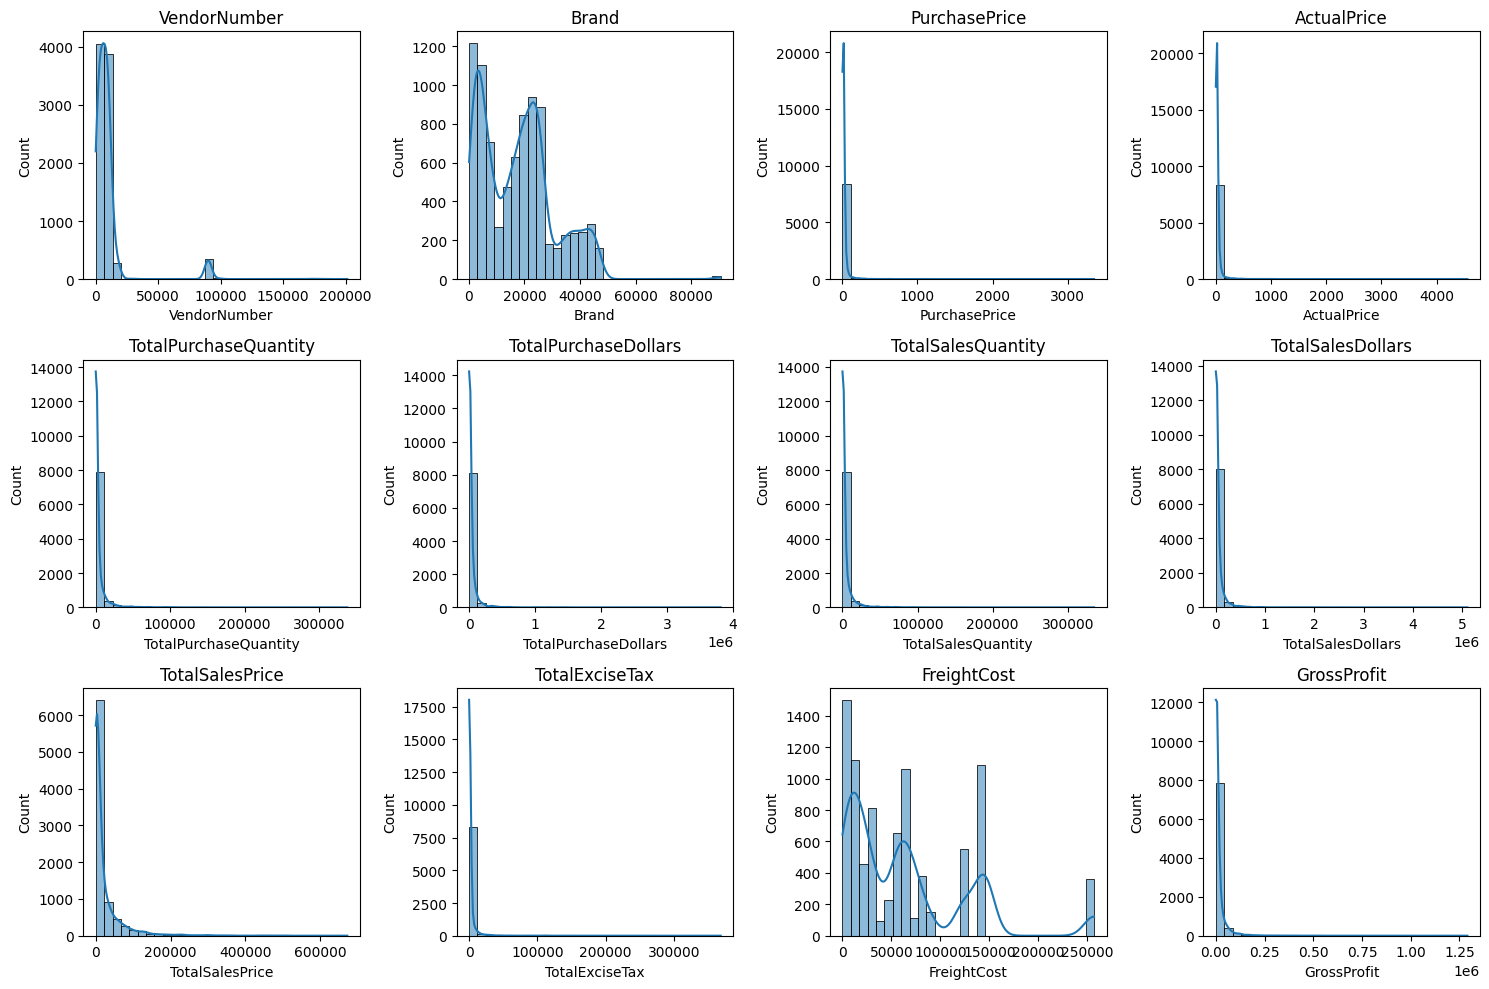

In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns[:12]

plt.figure(figsize=(15, 10))

for i, col in enumerate(numerical_cols):
    plt.subplot(3, 4, i + 1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)

plt.tight_layout()
plt.show()


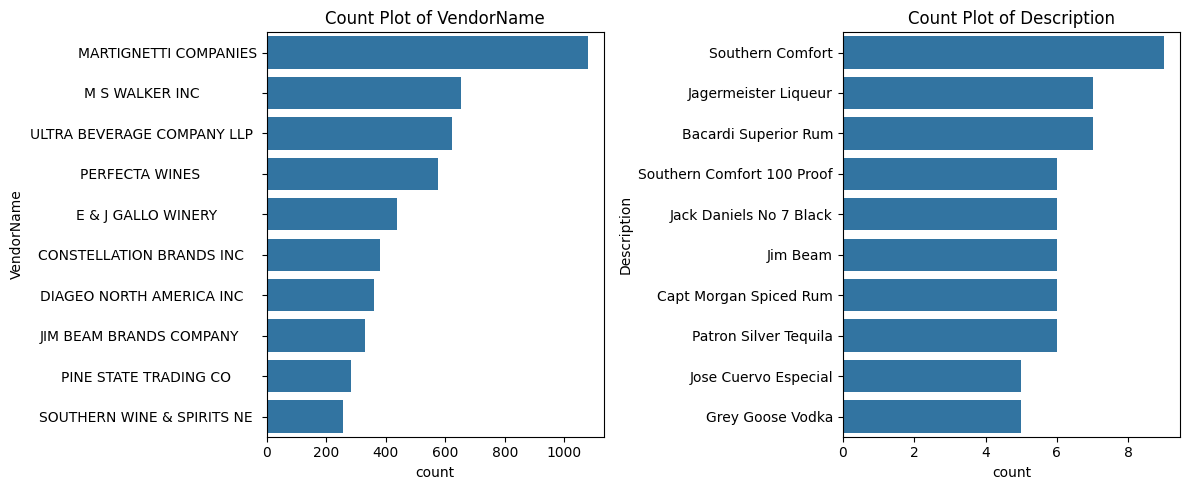

In [ ]:
# Count Plots for Categorical Columns
categorical_cols = ["VendorName", "Description"]

plt.figure(figsize=(12, 5))

for i, col in enumerate(categorical_cols):
    plt.subplot(1, 2, i + 1)

    # Plot only top 10 most frequent categories
    sns.countplot(
        y=df[col],
        order=df[col].value_counts().index[:10]
    )

    plt.title(f"Count Plot of {col}")

plt.tight_layout()
plt.show()


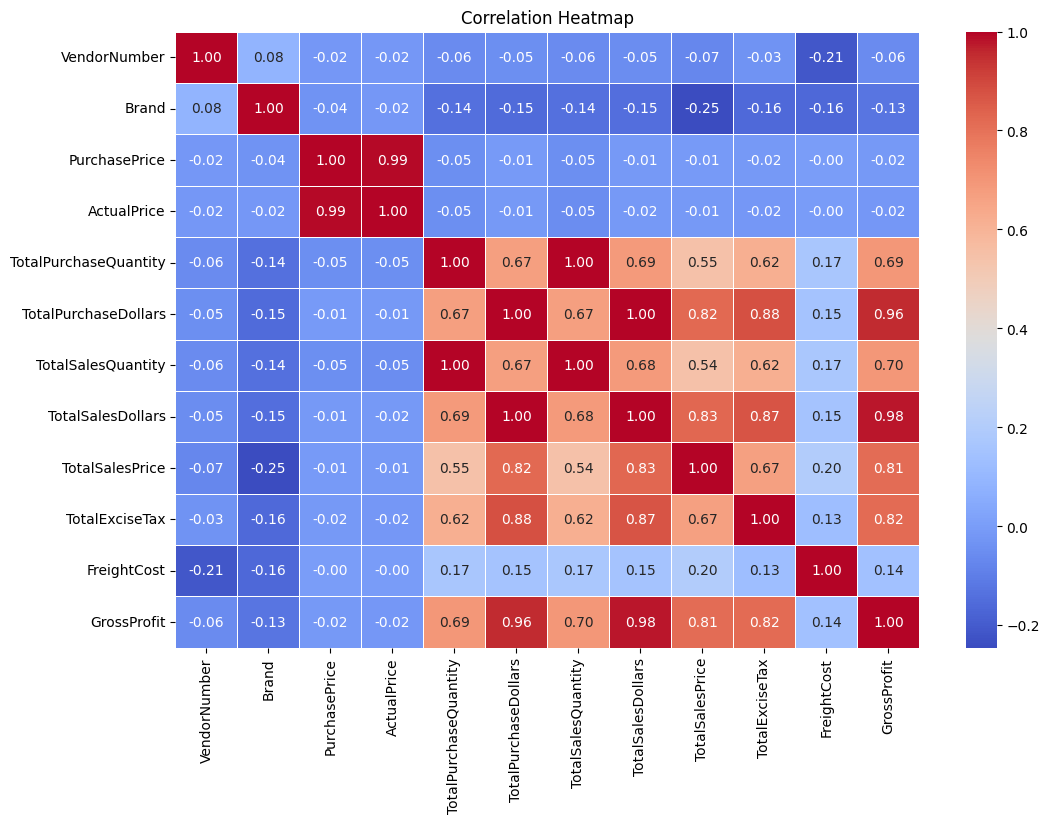

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))

correlation_matrix = df[numerical_cols].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()


In [ ]:
# Brand Performance Analysis
brand_performance = (
    df.groupby("Description")
      .agg({
          "TotalSalesDollars": "sum",
          "ProfitMargin": "mean"
      })
      .reset_index()
)

brand_performance.head()


,Description,TotalSalesDollars,ProfitMargin
0,(RI) 1,21519.09,18.060661
1,.nparalleled Svgn Blanc,1094.63,29.978166
2,10 Span Cab Svgn CC,2703.89,20.937612
3,10 Span Chard CC,3325.56,27.806445
4,10 Span Pnt Gris Monterey Cy,2082.22,32.226182


In [ ]:
# Define thresholds using quantiles
low_sales_threshold = brand_performance["TotalSalesDollars"].quantile(0.15)
high_margin_threshold = brand_performance["ProfitMargin"].quantile(0.85)

low_sales_threshold, high_margin_threshold


(np.float64(560.299), np.float64(64.97017552750111))

In [ ]:
# Brands with low sales but high profit margins
target_brands = brand_performance[
    (brand_performance["TotalSalesDollars"] <= low_sales_threshold) &
    (brand_performance["ProfitMargin"] >= high_margin_threshold)
]

print("Brands with Low Sales but High Profit Margins:")
display(target_brands.sort_values("TotalSalesDollars"))


Brands with Low Sales but High Profit Margins:


,Description,TotalSalesDollars,ProfitMargin
6199,Santa Rita Organic Svgn Bl,9.99,66.466466
2369,Debauchery Pnt Nr,11.58,65.975820
2070,Concannon Glen Ellen Wh Zin,15.95,83.448276
2188,Crown Royal Apple,27.86,89.806174
6237,Sauza Sprklg Wild Berry Marg,27.96,82.153076
...,...,...,...
5074,Nanbu Bijin Southern Beauty,535.68,76.747312
2271,Dad's Hat Rye Whiskey,538.89,81.851584
57,A Bichot Clos Marechaudes,539.94,67.740860
6245,Sbragia Home Ranch Merlot,549.75,66.444748


In [ ]:
# Filter brands with very high sales for better visualization
filtered_brand_performance = brand_performance[
    brand_performance["TotalSalesDollars"] < 10000
]


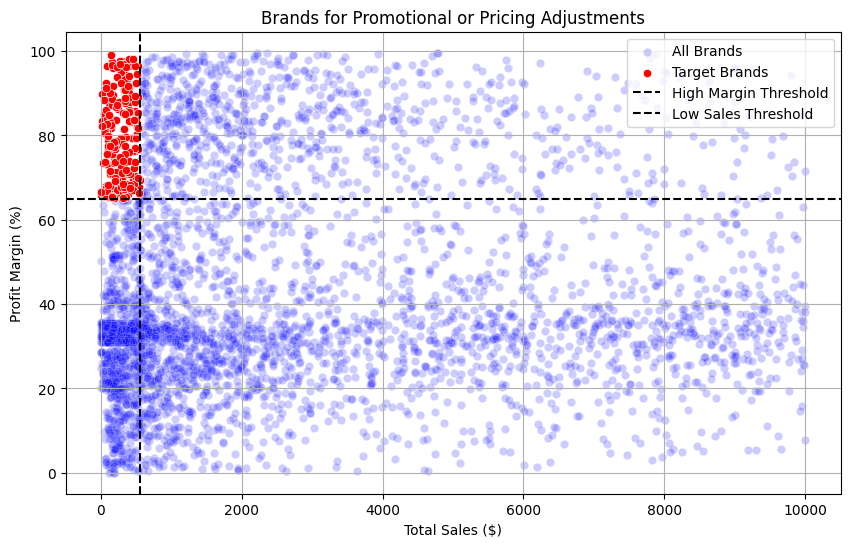

In [ ]:
plt.figure(figsize=(10, 6))

# All brands (filtered for visualization)
sns.scatterplot(
    data=filtered_brand_performance,
    x="TotalSalesDollars",
    y="ProfitMargin",
    color="blue",
    label="All Brands",
    alpha=0.2
)

# Target brands (low sales, high margin)
sns.scatterplot(
    data=target_brands,
    x="TotalSalesDollars",
    y="ProfitMargin",
    color="red",
    label="Target Brands"
)

# Threshold lines
plt.axhline(
    high_margin_threshold,
    linestyle="--",
    color="black",
    label="High Margin Threshold"
)

plt.axvline(
    low_sales_threshold,
    linestyle="--",
    color="black",
    label="Low Sales Threshold"
)

plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Brands for Promotional or Pricing Adjustments")
plt.legend()
plt.grid(True)
plt.show()


Which vendors and brands demonstrate the highest sales performance

In [ ]:
def format_dollars(value):
    if value >= 1_000_000:
        return f"{value / 1_000_000:.2f}M"
    elif value >= 1_000:
        return f"{value / 1_000:.2f}K"
    else:
        return str(round(value, 2))


In [ ]:
# Top Vendors & Brands by Sales Performance
top_vendors = (
    df.groupby("VendorName")["TotalSalesDollars"]
    .sum()
    .nlargest(10)
)

top_brands = (
    df.groupby("Description")["TotalSalesDollars"]
    .sum()
    .nlargest(10)
)

top_vendors


,TotalSalesDollars
VendorName,
DIAGEO NORTH AMERICA INC,6.873983e+07
MARTIGNETTI COMPANIES,4.090521e+07
PERNOD RICARD USA,3.227954e+07
JIM BEAM BRANDS COMPANY,3.189862e+07
BACARDI USA INC,2.500537e+07
CONSTELLATION BRANDS INC,2.446713e+07
E & J GALLO WINERY,1.855377e+07
BROWN-FORMAN CORP,1.847661e+07
ULTRA BEVERAGE COMPANY LLP,1.780265e+07


In [ ]:
top_brands

,TotalSalesDollars
Description,
Jack Daniels No 7 Black,7964746.76
Tito's Handmade Vodka,7399657.58
Grey Goose Vodka,7209608.06
Capt Morgan Spiced Rum,6356320.62
Absolut 80 Proof,6244752.03
Jameson Irish Whiskey,5715759.69
Ketel One Vodka,5070083.56
Baileys Irish Cream,4150122.07
Kahlua,3604858.66


In [ ]:
# Format Top Vendors sales values
top_vendors.apply(lambda x: format_dollars(x))


,TotalSalesDollars
VendorName,
DIAGEO NORTH AMERICA INC,68.74M
MARTIGNETTI COMPANIES,40.91M
PERNOD RICARD USA,32.28M
JIM BEAM BRANDS COMPANY,31.90M
BACARDI USA INC,25.01M
CONSTELLATION BRANDS INC,24.47M
E & J GALLO WINERY,18.55M
BROWN-FORMAN CORP,18.48M
ULTRA BEVERAGE COMPANY LLP,17.80M


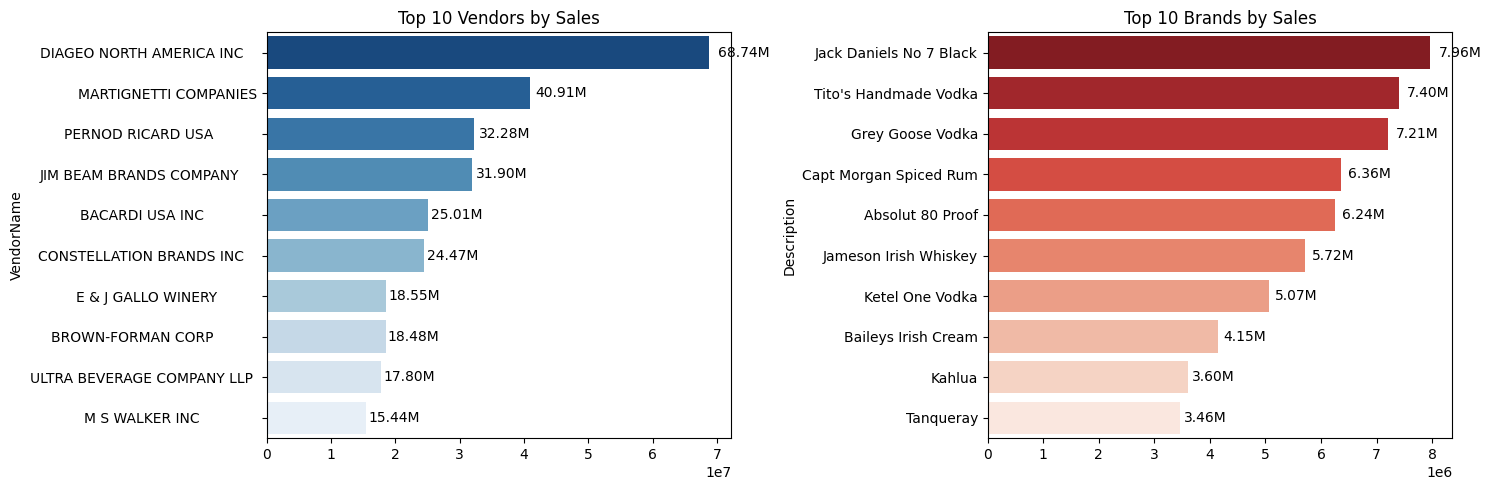

In [ ]:
plt.figure(figsize=(15, 5))

# -----------------------------
# Plot for Top Vendors
# -----------------------------
plt.subplot(1, 2, 1)
ax1 = sns.barplot(
    y=top_vendors.index,
    x=top_vendors.values,
    palette="Blues_r"
)
plt.title("Top 10 Vendors by Sales")

# Add value labels to vendor bars
for bar in ax1.patches:
    ax1.text(
        bar.get_width() + (bar.get_width() * 0.02),
        bar.get_y() + bar.get_height() / 2,
        format_dollars(bar.get_width()),
        ha="left",
        va="center",
        fontsize=10,
        color="black"
    )

# -----------------------------
# Plot for Top Brands
# -----------------------------
plt.subplot(1, 2, 2)
ax2 = sns.barplot(
    y=top_brands.index.astype(str),
    x=top_brands.values,
    palette="Reds_r"
)
plt.title("Top 10 Brands by Sales")

# Add value labels to brand bars
for bar in ax2.patches:
    ax2.text(
        bar.get_width() + (bar.get_width() * 0.02),
        bar.get_y() + bar.get_height() / 2,
        format_dollars(bar.get_width()),
        ha="left",
        va="center",
        fontsize=10,
        color="black"
    )

plt.tight_layout()
plt.show()


Which vendors contribute the most to total purchase dollars ?

In [ ]:
# Which vendors contribute the most to total purchase dollars?

vendor_performance = df.groupby("VendorName").agg({
    "TotalPurchaseDollars": "sum",
    "GrossProfit": "sum",
    "TotalSalesDollars": "sum"
}).reset_index()

vendor_performance.head()


,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars
0,AAPER ALCOHOL & CHEMICAL CO,105.07,-105.07,0.00
1,ADAMBA IMPORTS INTL INC,76770.25,-9194.03,67576.22
2,ALISA CARR BEVERAGES,34951.68,78638.50,113590.18
3,ALTAMAR BRANDS LLC,11706.20,4000.61,15706.81
4,AMERICAN SPIRITS EXCHANGE,1205.16,514.81,1719.97


In [ ]:
vendor_performance['PurchaseContribution%'] = (
    vendor_performance['TotalPurchaseDollars'] /
    vendor_performance['TotalPurchaseDollars'].sum()
) * 100

vendor_performance


,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
0,ADAMBA IMPORTS INTL INC,446.16,258.37,704.53,0.000145
1,ALISA CARR BEVERAGES,25698.12,78772.82,104470.94,0.008361
2,ALTAMAR BRANDS LLC,11706.20,4000.61,15706.81,0.003809
3,AMERICAN SPIRITS EXCHANGE,934.08,577.08,1511.16,0.000304
4,AMERICAN VINTAGE BEVERAGE,104435.68,35167.85,139603.53,0.033981
...,...,...,...,...,...
115,WEIN BAUER INC,42694.64,13522.49,56217.13,0.013892
116,WESTERN SPIRITS BEVERAGE CO,298416.86,106837.97,405254.83,0.097097
117,WILLIAM GRANT & SONS INC,5876538.26,1693337.94,7569876.20,1.912073
118,WINE GROUP INC,5203801.17,3100242.11,8304043.28,1.693182


In [ ]:
# Sort vendors by purchase contribution and round values
vendor_performance_sorted = (
    vendor_performance
    .sort_values('PurchaseContribution%', ascending=False)
    .round(2)
)

vendor_performance_sorted



,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
25,DIAGEO NORTH AMERICA INC,50097226.16,17892873.26,67990099.42,16.30
57,MARTIGNETTI COMPANIES,25464774.04,13811624.76,39276398.80,8.29
69,PERNOD RICARD USA,23851164.17,8212032.02,32063196.19,7.76
46,JIM BEAM BRANDS COMPANY,23494304.32,7928716.14,31423020.46,7.64
6,BACARDI USA INC,17432020.26,7422796.88,24854817.14,5.67
...,...,...,...,...,...
33,FANTASY FINE WINES CORP,128.64,198.95,327.59,0.00
108,UNCORKED,118.74,58.20,176.94,0.00
86,SILVER MOUNTAIN CIDERS,77.18,265.33,342.51,0.00
16,CAPSTONE INTERNATIONAL,54.64,192.23,246.87,0.00


In [ ]:
# Helper function to format large dollar values
def format_dollars(value):
    if value >= 1_000_000:
        return f"{value / 1_000_000:.2f}M"
    elif value >= 1_000:
        return f"{value / 1_000:.2f}K"
    else:
        return f"{value:.2f}"


In [ ]:
# Display Top 10 Vendors by Purchase Contribution
top_vendors = (
    vendor_performance
    .sort_values('PurchaseContribution%', ascending=False)
    .head(10)
    .copy()
)

# Format dollar columns for readability
top_vendors['TotalSalesDollars'] = top_vendors['TotalSalesDollars'].apply(format_dollars)
top_vendors['TotalPurchaseDollars'] = top_vendors['TotalPurchaseDollars'].apply(format_dollars)
top_vendors['GrossProfit'] = top_vendors['GrossProfit'].apply(format_dollars)

top_vendors



,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
25,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,16.300334
57,MARTIGNETTI COMPANIES,25.46M,13.81M,39.28M,8.285575
69,PERNOD RICARD USA,23.85M,8.21M,32.06M,7.760548
46,JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,7.644435
6,BACARDI USA INC,17.43M,7.42M,24.85M,5.671926
20,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,4.969667
11,BROWN-FORMAN CORP,13.24M,5.01M,18.25M,4.307606
30,E & J GALLO WINERY,12.07M,6.33M,18.40M,3.926789
107,ULTRA BEVERAGE COMPANY LLP,11.17M,5.34M,16.50M,3.633478
53,M S WALKER INC,9.76M,4.94M,14.71M,3.177053


In [ ]:
# Calculate cumulative purchase contribution
top_vendors['Cumulative_Contribution%'] = (
    top_vendors['PurchaseContribution%'].cumsum()
)

top_vendors


,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%,Cumulative_Contribution%
25,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,16.300334,16.300334
57,MARTIGNETTI COMPANIES,25.46M,13.81M,39.28M,8.285575,24.585909
69,PERNOD RICARD USA,23.85M,8.21M,32.06M,7.760548,32.346458
46,JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,7.644435,39.990893
6,BACARDI USA INC,17.43M,7.42M,24.85M,5.671926,45.662819
20,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,4.969667,50.632486
11,BROWN-FORMAN CORP,13.24M,5.01M,18.25M,4.307606,54.940093
30,E & J GALLO WINERY,12.07M,6.33M,18.40M,3.926789,58.866881
107,ULTRA BEVERAGE COMPANY LLP,11.17M,5.34M,16.50M,3.633478,62.500359
53,M S WALKER INC,9.76M,4.94M,14.71M,3.177053,65.677412


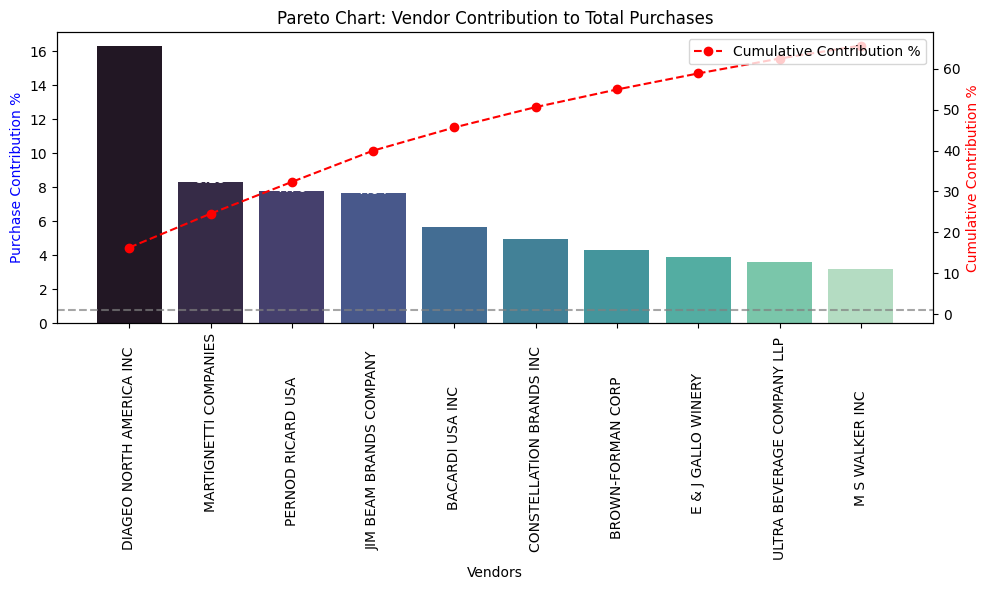

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create figure and primary axis
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar plot for Purchase Contribution %
sns.barplot(
    x=top_vendors['VendorName'],
    y=top_vendors['PurchaseContribution%'],
    palette="mako",
    ax=ax1
)

# Add percentage labels on bars
for i, value in enumerate(top_vendors['PurchaseContribution%']):
    ax1.text(
        i,
        value - 0.01,
        f"{value:.2f}",
        ha='center',
        fontsize=10,
        color='white'
    )

# Secondary axis for cumulative contribution
ax2 = ax1.twinx()
ax2.plot(
    top_vendors['VendorName'],
    top_vendors['Cumulative_Contribution%'],
    color='red',
    marker='o',
    linestyle='dashed',
    label='Cumulative Contribution %'
)

# Axis labels and title
ax1.set_ylabel('Purchase Contribution %', color='blue')
ax2.set_ylabel('Cumulative Contribution %', color='red')
ax1.set_xlabel('Vendors')
ax1.set_title('Pareto Chart: Vendor Contribution to Total Purchases')

# X-axis formatting
ax1.set_xticklabels(top_vendors['VendorName'], rotation=90)

# Reference line at 100%
ax2.axhline(y=1.0, color='gray', linestyle='dashed', alpha=0.7)

# Legend
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()


How much total procurement is dependent on the top vendors?

In [ ]:
print(
    f"Total Purchase Contribution of top 10 vendors is "
    f"{round(top_vendors['PurchaseContribution%'].sum(), 2)} %"
)


Total Purchase Contribution of top 10 vendors is 65.68 %


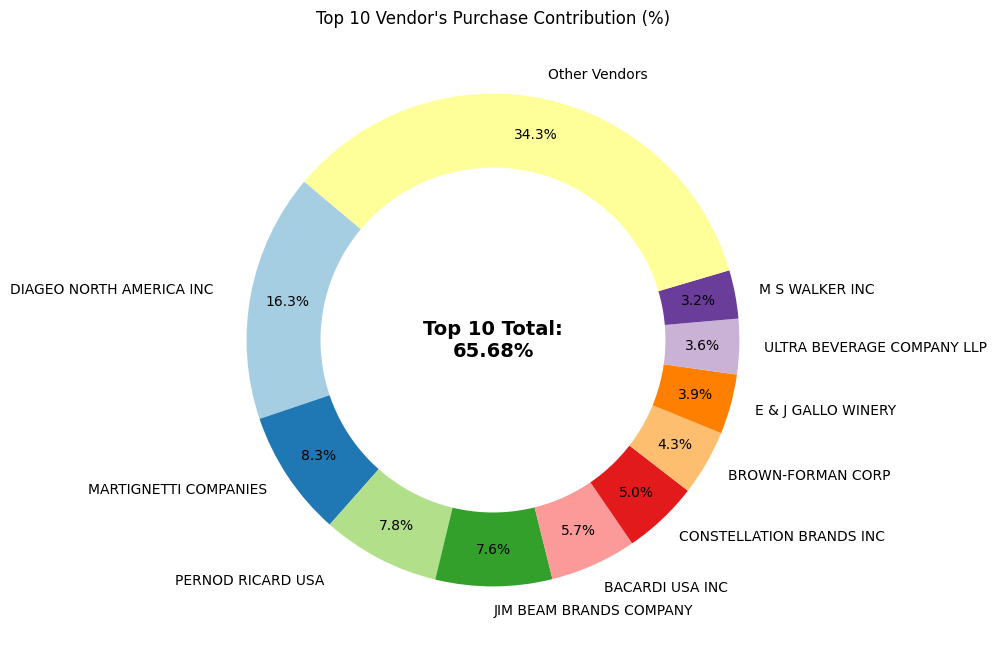

In [ ]:
# Prepare data
vendors = list(top_vendors['VendorName'].values)
purchase_contributions = list(top_vendors['PurchaseContribution%'].values)

total_contribution = sum(purchase_contributions)
remaining_contribution = 100 - total_contribution

# Append "Other Vendors"
vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)

# Donut Chart
fig, ax = plt.subplots(figsize=(8, 8))

wedges, texts, autotexts = ax.pie(
    purchase_contributions,
    labels=vendors,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.85,
    colors=plt.cm.Paired.colors
)

# Donut hole
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
ax.add_artist(centre_circle)

# Center text (THIS WAS WRONG BEFORE)
plt.text(
    0, 0,
    f"Top 10 Total:\n{total_contribution:.2f}%",
    ha='center',
    va='center',
    fontsize=14,
    fontweight='bold'
)

plt.title("Top 10 Vendor's Purchase Contribution (%)")
plt.show()


Does purchasing in bulk reduce the price,and what is the optimal purchse volume fo r cost savings?

In [ ]:
df['UnitPurchasePrice'] = df['TotalPurchaseDollars'] / df['TotalPurchaseQuantity']

In [ ]:
df["OrderSize"] = pd.qcut(
    df["TotalPurchaseQuantity"],
    q=3,
    labels=["Small", "Medium", "Large"]
)

In [ ]:
df[["OrderSize", "TotalPurchaseQuantity"]]

,OrderSize,TotalPurchaseQuantity
0,Large,145080
1,Large,164038
2,Large,187407
3,Large,201682
4,Large,138109
...,...,...
8560,Small,2
8561,Small,6
8562,Small,2
8563,Small,1


In [ ]:
df.groupby("OrderSize")[["UnitPurchasePrice"]].mean()


,UnitPurchasePrice
OrderSize,
Small,39.057543
Medium,15.486414
Large,10.777625


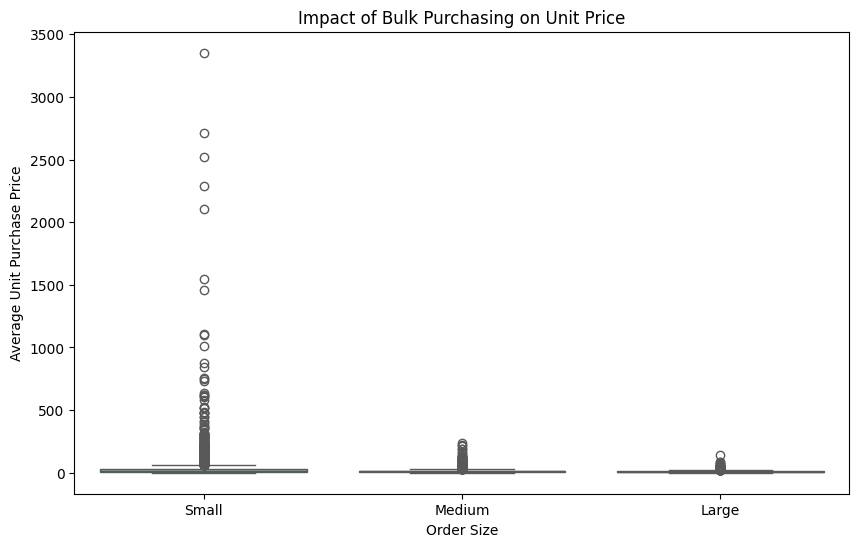

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x="OrderSize",
    y="UnitPurchasePrice",
    palette="Set2"
)
plt.title("Impact of Bulk Purchasing on Unit Price")
plt.xlabel("Order Size")
plt.ylabel("Average Unit Purchase Price")
plt.show()


Which vendors have low turnover,indicating low turnover stock and slow moving products?

In [ ]:
df[df['StockTurnover'] < 1] \
    .groupby('VendorName')[['StockTurnover']] \
    .mean() \
    .sort_values('StockTurnover', ascending=True) \
    .head(10)


,StockTurnover
VendorName,
ALISA CARR BEVERAGES,0.615385
HIGHLAND WINE MERCHANTS LLC,0.708333
PARK STREET IMPORTS LLC,0.751306
Circa Wines,0.755676
Dunn Wine Brokers,0.766022
CENTEUR IMPORTS LLC,0.773953
SMOKY QUARTZ DISTILLERY LLC,0.783835
TAMWORTH DISTILLING,0.797078
THE IMPORTED GRAPE LLC,0.807569


How much capital is locked in unsold inventory per vendor,and which vendors contribute the most to it?


In [ ]:
# How much capital is locked in unsold inventory per vendor, and which vendors contribute the most to it?

df["UnsoldInventoryValue"] = (
    (df["TotalPurchaseQuantity"] - df["TotalSalesQuantity"]) * df["PurchasePrice"]
)

print("Total Unsold Capital:", format_dollars(df["UnsoldInventoryValue"].sum()))


Total Unsold Capital: 2.71M


In [ ]:
# Aggregate Capital Locked per Vendor
inventory_value_per_vendor = (
    df.groupby("VendorName")["UnsoldInventoryValue"]
    .sum()
    .reset_index()
)

# Sort Vendors with the Highest Locked Capital
inventory_value_per_vendor = inventory_value_per_vendor.sort_values(
    by="UnsoldInventoryValue", ascending=False
)

inventory_value_per_vendor["UnsoldInventoryValue"] = (
    inventory_value_per_vendor["UnsoldInventoryValue"].apply(format_dollars)
)

inventory_value_per_vendor.head(10)


,VendorName,UnsoldInventoryValue
25,DIAGEO NORTH AMERICA INC,722.21K
46,JIM BEAM BRANDS COMPANY,554.67K
69,PERNOD RICARD USA,470.63K
117,WILLIAM GRANT & SONS INC,401.96K
30,E & J GALLO WINERY,228.28K
80,SAZERAC CO INC,198.44K
11,BROWN-FORMAN CORP,177.73K
20,CONSTELLATION BRANDS INC,133.62K
62,MOET HENNESSY USA INC,126.48K
78,REMY COINTREAU USA INC,118.60K


What is the 95% confidence intervals for profit margins of top performing and low performing vendors?

In [ ]:
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)


In [ ]:
top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()


In [ ]:
low_vendors

,ProfitMargin
5631,4.111764
5652,6.145626
5701,12.007271
5704,1.677308
5724,7.239599
...,...
8560,83.448276
8561,96.436186
8562,25.252525
8563,98.974037


In [ ]:
def confidence_interval(data, confidence=0.95):
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data))  # Standard error
    t_critical = stats.t.ppf((1 + confidence) / 2, df=len(data) - 1)
    margin_of_error = t_critical * std_err
    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error


Top Vendors 95% CI: (30.74, 31.61), Mean: 31.17
Low Vendors 95% CI: (40.48, 42.62), Mean: 41.55


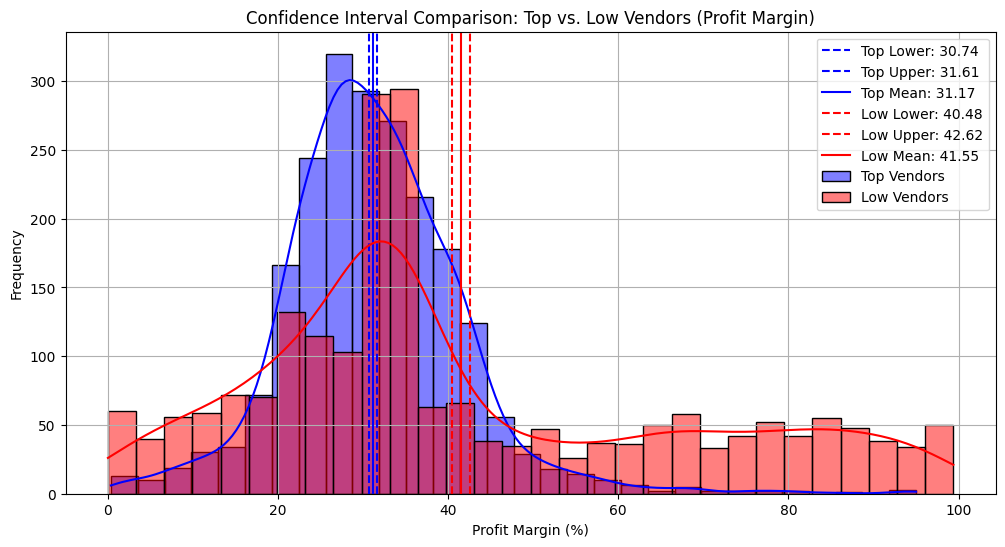

In [ ]:
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"Low Vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")

plt.figure(figsize=(12, 6))

# Top Vendors Plot
sns.histplot(top_vendors, kde=True, color="blue", bins=30, alpha=0.5, label="Top Vendors")
plt.axvline(top_lower, color="blue", linestyle="--", label=f"Top Lower: {top_lower:.2f}")
plt.axvline(top_upper, color="blue", linestyle="--", label=f"Top Upper: {top_upper:.2f}")
plt.axvline(top_mean, color="blue", linestyle="-", label=f"Top Mean: {top_mean:.2f}")

# Low Vendors Plot
sns.histplot(low_vendors, kde=True, color="red", bins=30, alpha=0.5, label="Low Vendors")
plt.axvline(low_lower, color="red", linestyle="--", label=f"Low Lower: {low_lower:.2f}")
plt.axvline(low_upper, color="red", linestyle="--", label=f"Low Upper: {low_upper:.2f}")
plt.axvline(low_mean, color="red", linestyle="-", label=f"Low Mean: {low_mean:.2f}")

# Finalize Plot
plt.title("Confidence Interval Comparison: Top vs. Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()

# Perform Two-Sample T-Test
t_stat, p_value = ttest_ind(top_vendors, low_vendors, equal_var=False)

# Print results
print(f"T-Statistic: {t_stat:.4f}, P-Value: {p_value:.4f}")
if p_value < 0.05:
    print("Reject H₀: There is a significant difference in profit margins between top and low-performing vendors.")
else:
    print("Fail to Reject H₀: No significant difference in profit margins.")


T-Statistic: -17.6440, P-Value: 0.0000
Reject H₀: There is a significant difference in profit margins between top and low-performing vendors.


In [ ]:
import os

os.path.exists("/content/drive/MyDrive/data/inventory.db")


False